In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

The Hotel Booking dataset contains information about hotel reservations and is used to predict whether a customer will cancel the booking (churn) or not.

I selected this dataset because it not only represents a real-world churn problem but also provides sufficient complexity in terms of data preprocessing, feature engineering, and model building. It allowed me to demonstrate end-to-end machine learning skills, from handling missing data to building predictive models that can generate actionable business insights.

Problem Type: Classification  
Target Variable: is_cancele  

In [ ]:
df=pd.read_csv("/content/hotel_bookingss.csv")

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      119390 non-null  int64  
 1   hotel                           119390 non-null  object 
 2   is_canceled                     119390 non-null  object 
 3   lead_time                       119390 non-null  int64  
 4   arrival_date_year               119390 non-null  int64  
 5   arrival_date_month              119390 non-null  object 
 6   arrival_date_week_number        119390 non-null  int64  
 7   arrival_date_day_of_month       119390 non-null  int64  
 8   stays_in_weekend_nights         119390 non-null  int64  
 9   stays_in_week_nights            119390 non-null  int64  
 10  adults                          119390 non-null  int64  
 11  children                        119386 non-null  float64
 12  babies          

In [ ]:
df.columns

Index(['Unnamed: 0', 'hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Columns Distribution :  
Customer Information :- adults, children, babies  
Booking Details      :- lead_time, arrival_date_month, stays_in_weekend_nights  
Pricing Information  :- adr  
Pricing Information  :-previous_cancellations,
booking_changes  

In [ ]:
df.drop(columns="Unnamed: 0",axis=1,inplace=True)

In [ ]:
df.sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
80873,City Hotel,No,73,2015,November,48,24,0,3,2,...,No Deposit,12.0,NaN,27,Transient-Party,85.67,0,0,Check-Out,2015-11-27
56524,City Hotel,Yes,426,2016,September,37,8,0,2,2,...,Non Refund,1.0,NaN,0,Transient,62.00,0,0,Canceled,2015-10-21
50743,City Hotel,Yes,126,2016,May,19,7,0,1,2,...,No Deposit,9.0,NaN,0,Transient,103.50,0,0,Canceled,2016-02-05
10195,Resort Hotel,Yes,0,2017,February,8,19,1,0,2,...,No Deposit,250.0,NaN,0,Transient-Party,80.00,0,0,Canceled,2017-02-19
108575,City Hotel,No,206,2017,March,13,26,2,1,2,...,No Deposit,296.0,NaN,0,Transient-Party,72.00,0,0,Check-Out,2017-03-29
33151,Resort Hotel,No,9,2017,February,7,15,0,2,1,...,No Deposit,NaN,154.0,0,Transient,35.00,0,0,Check-Out,2017-02-17
11649,Resort Hotel,Yes,92,2017,May,21,24,0,1,2,...,No Deposit,241.0,NaN,0,Transient,68.00,0,1,Canceled,2017-04-09
104754,City Hotel,No,0,2017,January,3,21,0,1,1,...,No Deposit,7.0,NaN,0,Transient,60.06,0,0,Check-Out,2017-01-22
7398,Resort Hotel,Yes,148,2016,August,33,7,2,4,2,...,No Deposit,240.0,NaN,0,Transient,269.00,0,0,Canceled,2016-06-14
107644,City Hotel,No,211,2017,March,11,13,1,2,1,...,No Deposit,8.0,NaN,0,Transient,85.50,0,1,Check-Out,2017-03-16


In [ ]:
## Why I Chose This Dataset

:I selected this dataset because it not only represents a real-world churn problem but also provides sufficient complexity in terms of data preprocessing, feature engineering, and model building. It allowed me to demonstrate end-to-end machine learning skills, from handling missing data to building predictive models that can generate actionable business insights.

# Slipting Data Into two part such as categorical and numerical

In [ ]:
num_df = df.select_dtypes(include=(int,float))
cat_df = df.select_dtypes(include=object)

## Categorical Data

In [ ]:
cat_df.sample(5)

,hotel,is_canceled,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
35671,Resort Hotel,No,April,Undefined,SWE,Groups,TA/TO,A,A,No Deposit,Transient-Party,Check-Out,2017-04-29
71353,City Hotel,Yes,July,BB,IRL,Online TA,TA/TO,D,D,No Deposit,Transient,Canceled,2017-05-17
15588,Resort Hotel,No,July,HB,PRT,Online TA,TA/TO,C,C,No Deposit,Transient,Check-Out,2015-07-27
99369,City Hotel,No,October,BB,DNK,Online TA,TA/TO,F,F,No Deposit,Transient,Check-Out,2016-10-13
49685,City Hotel,Yes,April,HB,PRT,Offline TA/TO,TA/TO,A,A,Non Refund,Transient,Canceled,2015-08-04


## Data Cleaning for Categorical data

In [ ]:
# Check missing values
cat_df.isnull().sum()

,0
hotel,0
is_canceled,0
arrival_date_month,0
meal,0
country,488
market_segment,0
distribution_channel,0
reserved_room_type,0
assigned_room_type,0
deposit_type,0


In [ ]:
for i in  cat_df:
  print("--"*5,i,"--"*5)
  print(cat_df[i].value_counts())
  print()


---------- hotel ----------
hotel
Resort Hotel    40060
City Hotel       1691
Name: count, dtype: int64

---------- is_canceled ----------
is_canceled
No     30015
Yes    11736
Name: count, dtype: int64

---------- arrival_date_month ----------
arrival_date_month
August       6084
July         5073
April        3609
May          3559
October      3555
March        3336
September    3108
February     3103
June         3045
December     2648
November     2437
January      2193
Augu            1
Name: count, dtype: int64

---------- meal ----------
meal
BB           31143
HB            8519
Undefined     1169
FB             754
SC             165
Name: count, dtype: int64

---------- country ----------
country
PRT    18620
GBR     6820
ESP     4169
IRL     2169
FRA     1692
       ...  
NPL        1
MAC        1
TGO        1
DJI        1
STP        1
Name: count, Length: 126, dtype: int64

---------- market_segment ----------
market_segment
Online TA        18205
Offline TA/TO     7890
Di

In [ ]:
cat_df.shape

(119390, 13)

In [ ]:
cat_df.columns

Index(['hotel', 'is_canceled', 'arrival_date_month', 'meal', 'country',
       'market_segment', 'distribution_channel', 'reserved_room_type',
       'assigned_room_type', 'deposit_type', 'customer_type',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
cat_df.groupby(["arrival_date_month","is_canceled"])["is_canceled"].count()

arrival_date_month  is_canceled
April               No             6565
                    Yes            4524
August              No             8638
                    Yes            5239
December            No             4409
                    Yes            2371
February            No             5372
                    Yes            2696
January             No             4122
                    Yes            1807
July                No             7919
                    Yes            4742
June                No             6404
                    Yes            4535
March               No             6645
                    Yes            3149
May                 No             7114
                    Yes            4677
November            No             4672
                    Yes            2122
October             No             6914
                    Yes            4246
September           No             6392
                    Yes            4116
Name: is_canceled, dtype: int64

In [ ]:
cat_df.groupby(["meal","is_canceled"])["is_canceled"].count()

meal       is_canceled
BB         No             57800
           Yes            34510
FB         No               320
           Yes              478
HB         No              9479
           Yes             4984
SC         No              6684
           Yes             3966
Undefined  No               883
           Yes              286
Name: is_canceled, dtype: int64

In [ ]:
cat_df["country"].isna().sum()

np.int64(488)

In [ ]:
cat_df["country"].dropna(inplace=True)

In [ ]:
cat_df.groupby(["market_segment","is_canceled"])["is_canceled"].count()

market_segment  is_canceled
Aviation        No               185
                Yes               52
Complementary   No               646
                Yes               97
Corporate       No              4303
                Yes              992
Direct          No             10672
                Yes             1934
Groups          No              7714
                Yes            12097
Offline TA/TO   No             15908
                Yes             8311
Online TA       No             35738
                Yes            20739
Undefined       Yes                2
Name: is_canceled, dtype: int64

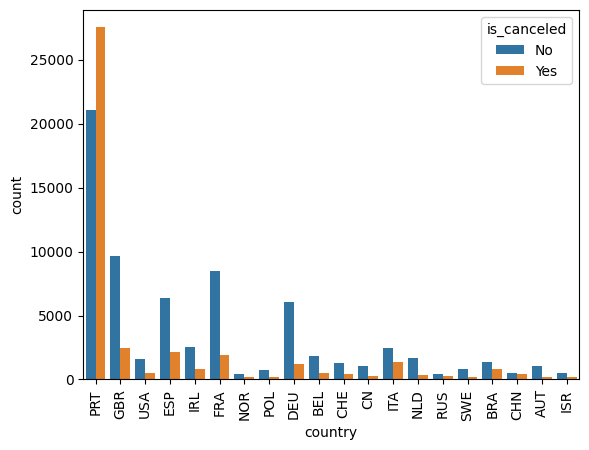

In [ ]:
top_countries = cat_df["country"].value_counts().head(20).index

filtered_df = cat_df[cat_df["country"].isin(top_countries)]

sns.countplot(data=filtered_df, x="country", hue="is_canceled")
plt.xticks(rotation=90)
plt.show()

## Data Cleaning for Numerical data

In [ ]:
num_df["is_canceled"]=cat_df["is_canceled"]
cat_df.drop(columns="is_canceled",inplace=True)

In [ ]:
round(num_df.isna().sum()/len(num_df)*100,2)

,0
lead_time,0.00
arrival_date_year,0.00
arrival_date_week_number,0.00
arrival_date_day_of_month,0.00
stays_in_weekend_nights,0.00
stays_in_week_nights,0.00
adults,0.00
children,0.00
babies,0.00
is_repeated_guest,0.00


In [ ]:
#  column agent has high percentage of missing value so we have to drop that column

num_df.drop(columns="company",inplace= True)

In [ ]:
num_df["agent"].value_counts()

,count
agent,
240.0,13905
250.0,2869
241.0,1721
40.0,1003
314.0,927
...,...
497.0,1
187.0,1
22.0,1


In [ ]:
num_df.columns

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'is_canceled'],
      dtype='object')

In [ ]:
num_df.groupby(["lead_time","is_canceled"])["is_canceled"].count()

lead_time  is_canceled
0          No             3244
           Yes             201
1          No             1578
           Yes             109
2          No              891
                          ... 
471        Yes               6
532        No                1
542        No               23
709        No                1
737        No                1
Name: is_canceled, Length: 783, dtype: int64

In [ ]:
num_df["lead_time"].value_counts()

,count
lead_time,
0,3445
1,1687
2,986
3,841
4,699
...,...
450,1
532,1
454,1


# Feature Engineering

Categorical Columns

In [ ]:
cat_df["is_canceled"]=cat_df["is_canceled"].map({"Yes":1,"No":0})

KeyError: 'is_canceled'

Numerical Columns


In [ ]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [ ]:
df['family'] = df['adults'] + df['children'] + df['babies']

In [ ]:
df.drop(columns=["stays_in_weekend_nights","stays_in_week_nights","adults","children","babies"],inplace=True)

In [ ]:
# resone behind it :- Feature engineering helped reduce dimensionality and improved interpretability

In [ ]:
df['cancel_risk'] = df['previous_cancellations'] / (df['previous_bookings_not_canceled'] + 1)

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay,family,cancel_risk
0,Resort Hotel,No,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0
1,Resort Hotel,No,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2.0,0.0
2,Resort Hotel,No,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,0.0
3,Resort Hotel,No,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,0.0
4,Resort Hotel,No,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2.0,0.0


In [ ]:
num_df["arrival_date_year"].value_counts()

,count
arrival_date_year,
2016,44167
2017,25087
2015,21995


# Visualizations

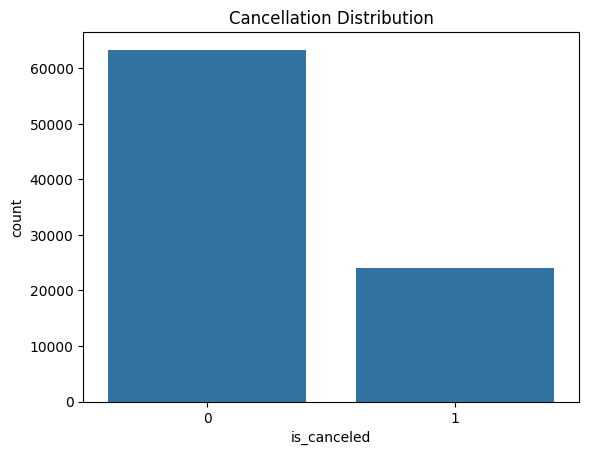

In [ ]:
sns.countplot(x='is_canceled', data=df)
plt.title("Cancellation Distribution")
plt.show()

In [ ]:
# The dataset shows class imbalance, which needs attention during modeling

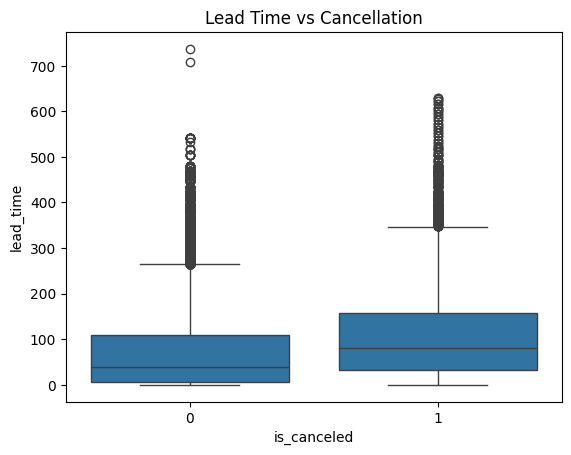

In [ ]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

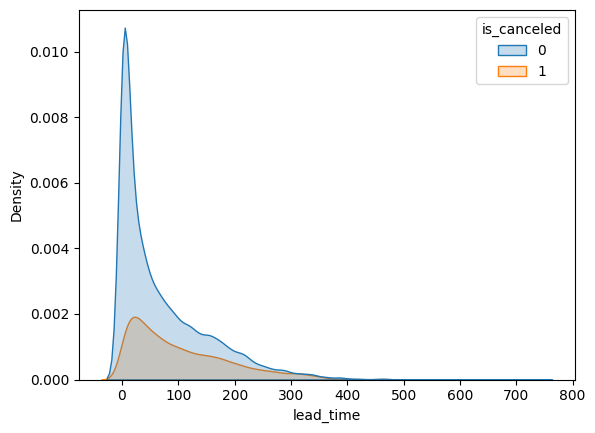

In [ ]:
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True)
plt.show()

Insight:  
Higher lead time → more cancellations  
Customers who book far in advance are more likely to cancel.  \

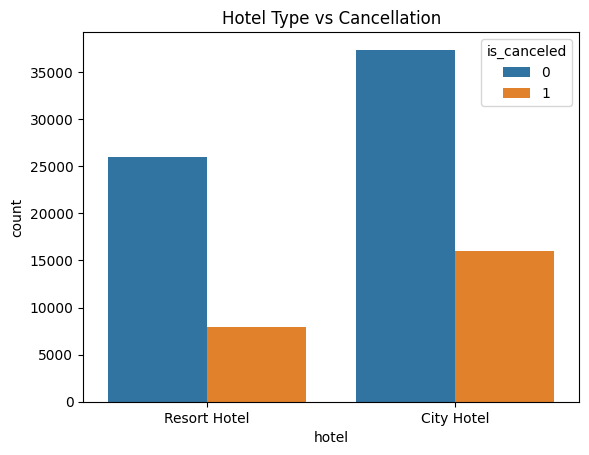

In [ ]:
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title("Hotel Type vs Cancellation")
plt.show()

Insight:  
City hotels → more cancellations

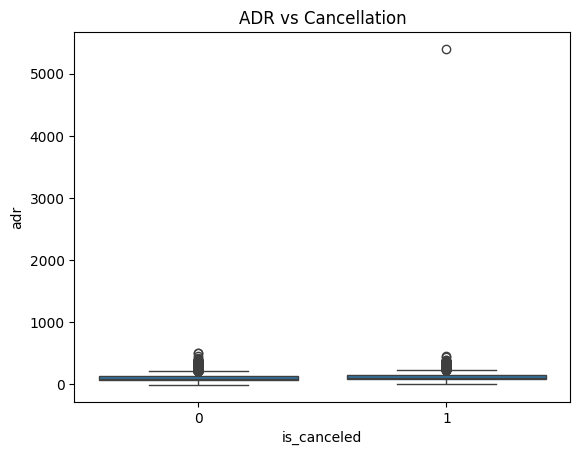

In [ ]:
sns.boxplot(x='is_canceled', y='adr', data=df)
plt.title("ADR vs Cancellation")
plt.show()

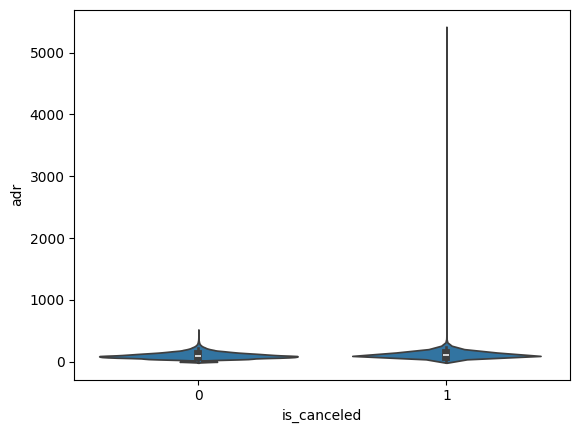

In [ ]:
sns.violinplot(x='is_canceled', y='adr', data=df)
plt.show()

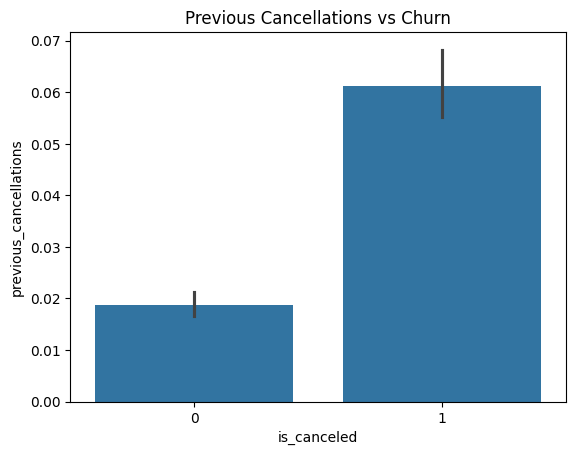

In [ ]:
sns.barplot(x='is_canceled', y='previous_cancellations', data=df)
plt.title("Previous Cancellations vs Churn")
plt.show()

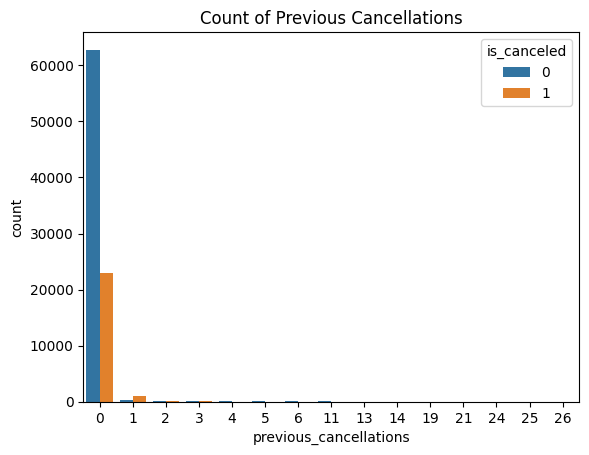

In [ ]:
sns.countplot(x='previous_cancellations', hue='is_canceled', data=df)
plt.title("Count of Previous Cancellations")
plt.show()

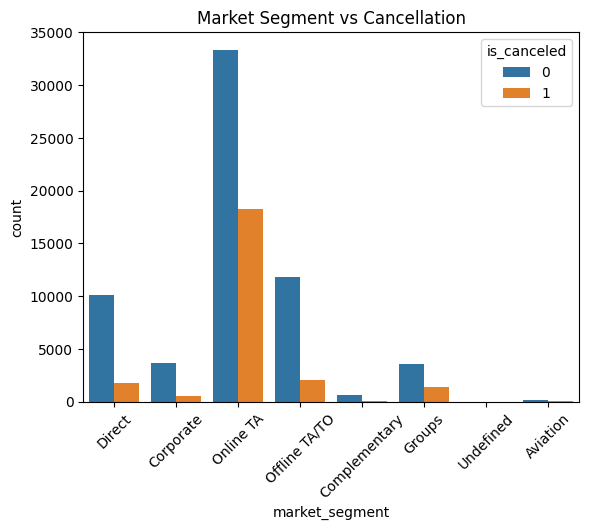

In [ ]:
sns.countplot(x='market_segment', hue='is_canceled', data=df)
plt.xticks(rotation=45)
plt.title("Market Segment vs Cancellation")
plt.show()

Insight:  
Some segments (like Online) cancel more





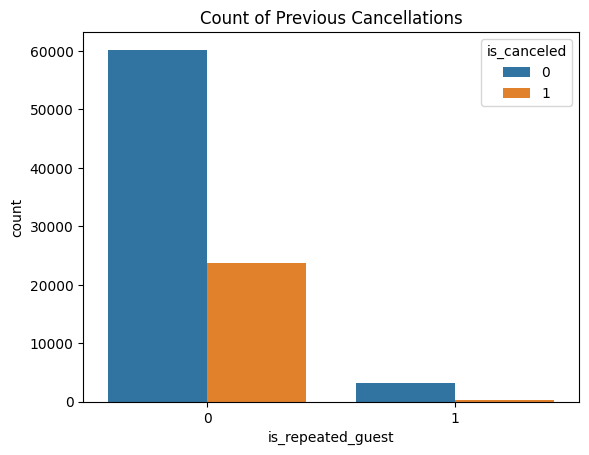

In [ ]:
sns.countplot(x="is_repeated_guest", hue='is_canceled', data=df)
plt.title("Count of Previous Cancellations")
plt.show()

no repeated customer has lead for cancel there booking

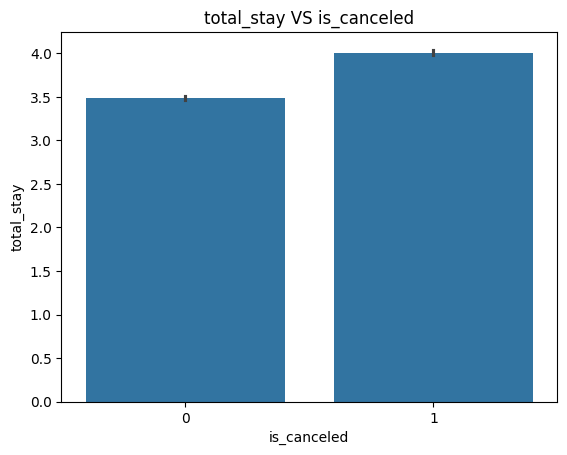

In [ ]:
sns.barplot(x='is_canceled', y='total_stay', data=df)
plt.title("total_stay VS is_canceled")
plt.show()

In [ ]:
sns.boxenplot

<function seaborn.categorical.boxenplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, dodge='auto', width=0.8, gap=0, linewidth=None, linecolor=None, width_method='exponential', k_depth='tukey', outlier_prop=0.007, trust_alpha=0.05, showfliers=True, hue_norm=None, log_scale=None, native_scale=False, formatter=None, legend='auto', scale=<deprecated>, box_kws=None, flier_kws=None, line_kws=None, ax=None, **kwargs)>

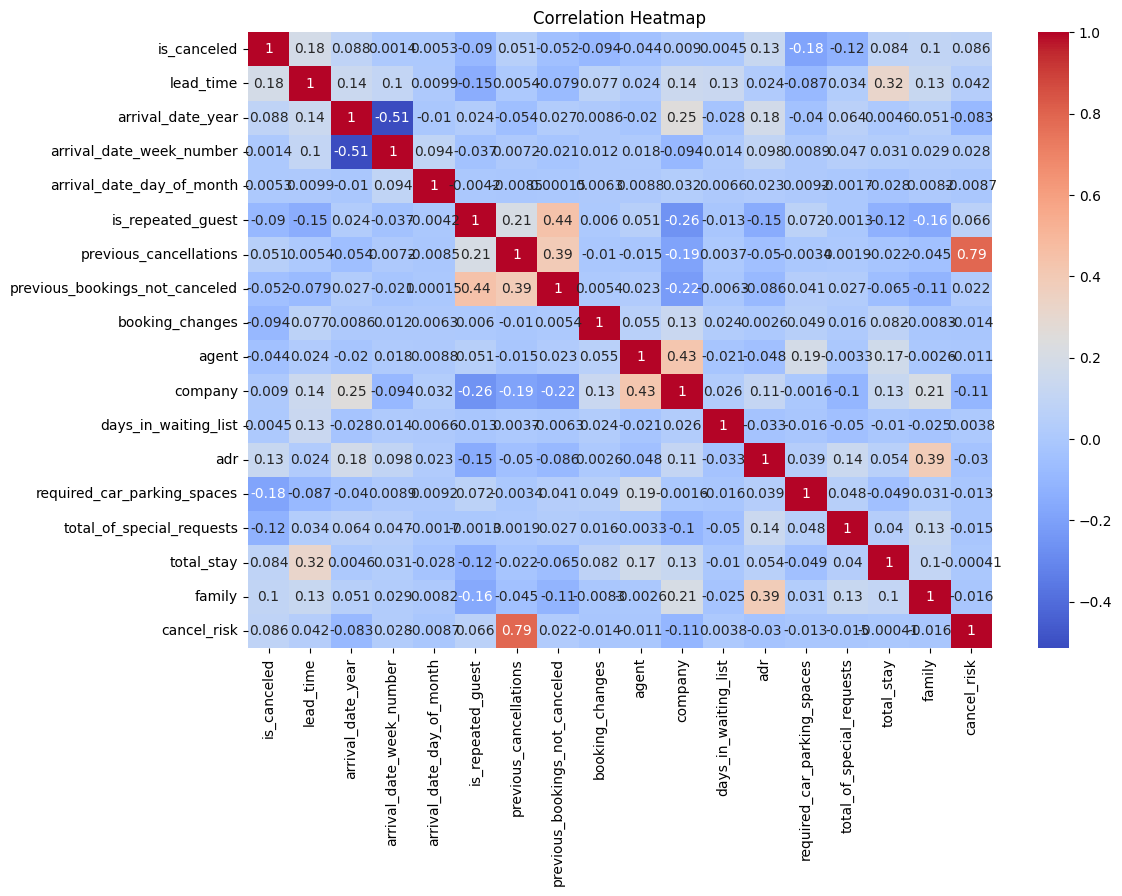

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm',annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_stay', 'family', 'cancel_risk'],
      dtype='object')

In [ ]:
# df.drop(columns="City Hotel",inplace=True)

In [ ]:
df["previous_cancellations"].value_counts()

,count
previous_cancellations,
0,85711
1,1407
2,112
3,61
4,30
11,27
5,19
6,17
13,4
